# NGC4254: extracting a KTZ-compatible spiral source field from the HII SFR map

This notebook takes the geometry and arm-profile model from the first two Python cells of `KTZ_validation.ipynb` and fits it to the `LOGSFR_SURFACE_DENSITY_HII` map in the current NGC4254 gas-bin product. It measures the global arm multiplicity `m_arms`, signed `pitch_angle`, reference phase `Theta0`, exponential scale `h_R`, modulation `eta`, and harmonic arrays `harmonic_n`, `harmonic_g`, and `harmonic_alpha`.

The result is a low-dimensional morphological description of the present HII SFR field. NGC4254 is lopsided and disturbed, so this is a best global logarithmic-spiral approximation, not proof that the galaxy contains a rigid, stationary density wave. Diffusion, enrichment-age, clustering, and pattern-speed parameters are outside this fit.


## 1. Model, conventions, and identifiability

The fitted linear source field is `lambda(R, phi) = lambda0_0 exp(-R/h_R) [1 + eta h(Theta)]`, where `Theta = (m/tan(pitch)) ln(R/R_ref) - m phi + Theta0`. The transverse arm profile is a harmonic series, `h(Theta) = sum g_n cos(n Theta + alpha_n)`.

Only the products `eta*g_n` are observable if every harmonic amplitude is free. We therefore fix `g_1 = 1` and `alpha_1 = 0`; the fundamental phase is carried by `Theta0`. This makes `eta` the fundamental modulation amplitude and makes the higher harmonic amplitudes and phases identifiable. Positive pitch and negative pitch represent opposite winding senses under the explicit disc-coordinate convention below.


## 2. Imports and visible configuration

This cell contains every path, geometry assumption, optimizer range, and random seed used later. The local MAUVE convention is distance 16.5 Mpc, inclination 39 degrees, position angle 243 degrees east of north, and the stated optical centre. The pitch search tests both winding directions and arm multiplicities one through four. Change these values here rather than hiding alternatives inside helper functions.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from scipy.optimize import least_squares

ROOT = Path.cwd().resolve()
FITS_PATH = ROOT / "v3tk_v7.6.8/NGC4254/NGC4254_gas_bin_maps_further.fits"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
BIN_HDU = "BIN_ID"

DISTANCE_MPC = 16.5
CENTER = SkyCoord("12h18m49.68s", "+14d25m05.52s", frame="icrs")
INCLINATION_DEG = 39.0
POSITION_ANGLE_DEG = 243.0  # east of north; equivalent line orientation is 63 deg
R_REF_KPC = 1.0
M_CANDIDATES = np.arange(1, 5, dtype=int)
PITCH_GRID_DEG = np.concatenate((np.linspace(-45.0, -5.0, 161),
                                 np.linspace(5.0, 45.0, 161)))
HARMONIC_N = np.array([1, 2, 3], dtype=int)
USE_ALL_VALID_HII_BINS = True
N_BOOTSTRAP = 24
N_BOOTSTRAP_SECTORS = 12
RNG_SEED = 4254
rng = np.random.default_rng(RNG_SEED)

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 115, "font.size": 10})
warnings.filterwarnings("default")
print(f"Project root: {ROOT}")
print(f"Input product: {FITS_PATH}")


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/Igniz/Desktop/ICRAR/further
Input product: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_gas_bin_maps_further.fits


## 3. Read the two FITS maps and validate their shared geometry

The SFR map stores logarithmic surface density, while `BIN_ID` records the adaptive gas bin assigned to every image pixel. The loader copies both arrays before the FITS handle closes, verifies identical shapes, and constructs a celestial WCS from the SFR extension. No missing HII pixels are filled, and no science product is changed. The printed counts are live diagnostics rather than fixed sample assumptions.


In [2]:
def load_maps(path, sfr_hdu=SFR_HDU, bin_hdu=BIN_HDU):
    'Read the log-SFR and bin-ID maps and return an independent celestial WCS.'
    if not path.exists():
        raise FileNotFoundError(path)
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name for hdu in hdul}
        missing = [name for name in (sfr_hdu, bin_hdu) if name not in names]
        if missing:
            raise KeyError(f"Missing required HDUs: {missing}")
        log_sfr = np.asarray(hdul[sfr_hdu].data, dtype=float).copy()
        bin_id = np.asarray(hdul[bin_hdu].data, dtype=float).copy()
        header = hdul[sfr_hdu].header.copy()
    if log_sfr.shape != bin_id.shape:
        raise ValueError(f"Map shape mismatch: {log_sfr.shape} versus {bin_id.shape}")
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("Target HDU does not contain a celestial WCS")
    return log_sfr, bin_id, header, wcs


log_sfr_map, bin_id_map, sfr_header, celestial_wcs = load_maps(FITS_PATH)
finite_sfr = np.isfinite(log_sfr_map)
print(f"Map shape: {log_sfr_map.shape}")
print(f"Finite HII SFR pixels: {finite_sfr.sum():,}")
print(f"Finite log SFR range: {np.nanmin(log_sfr_map):.3f} to {np.nanmax(log_sfr_map):.3f}")


Map shape: (1190, 1012)
Finite HII SFR pixels: 681,856
Finite log SFR range: -3.533 to 0.375


## 4. Collapse repeated pixels to one independent gas-bin record

Adaptive gas-bin values are copied to every member pixel, so treating all finite pixels as independent would produce false precision. This function builds one row per valid `BIN_ID`: the mean stored log SFR, pixel centroid, sky centroid, and member-pixel area. Later fits use the member area as an integration weight while bootstrap resampling operates on spatial sectors, not individual repeated pixels.


In [3]:
def build_bin_catalog(log_sfr, bin_id, wcs):
    'Return one centroid and one SFR measurement per valid adaptive gas bin.'
    valid = np.isfinite(log_sfr) & np.isfinite(bin_id) & (bin_id >= 0)
    yy, xx = np.nonzero(valid)
    ids = bin_id[valid].astype(np.int64)
    values = log_sfr[valid]
    unique_ids, inverse = np.unique(ids, return_inverse=True)
    area_pix = np.bincount(inverse).astype(float)
    x_centroid = np.bincount(inverse, weights=xx) / area_pix
    y_centroid = np.bincount(inverse, weights=yy) / area_pix
    mean_log_sfr = np.bincount(inverse, weights=values) / area_pix
    ra_deg, dec_deg = wcs.pixel_to_world_values(x_centroid, y_centroid)
    table = pd.DataFrame({
        "bin_id": unique_ids,
        "x_pix": x_centroid,
        "y_pix": y_centroid,
        "ra_deg": ra_deg,
        "dec_deg": dec_deg,
        "area_pix": area_pix,
        "log_sfr": mean_log_sfr,
        "sfr_linear": np.power(10.0, mean_log_sfr),
    })
    if len(table) < 100:
        raise ValueError(f"Only {len(table)} valid HII bins; spiral fitting is not supported")
    return table, valid


bin_table, valid_hii_pixels = build_bin_catalog(log_sfr_map, bin_id_map, celestial_wcs)
assert bin_table["bin_id"].is_unique
assert np.all(bin_table["area_pix"] > 0)
assert np.all(np.isfinite(bin_table["sfr_linear"]))
print(f"Independent valid HII gas bins: {len(bin_table):,}")
print(f"Median represented area: {bin_table['area_pix'].median():.0f} image pixels")
display(bin_table.head())


Independent valid HII gas bins: 32,552
Median represented area: 8 image pixels


,bin_id,x_pix,y_pix,ra_deg,dec_deg,area_pix,log_sfr,sfr_linear
0,58,586.0,471.0,184.706783,14.416218,1.0,-0.668133,0.214717
1,59,589.0,471.0,184.706611,14.416218,1.0,-0.744630,0.180040
2,63,584.0,472.0,184.706898,14.416273,1.0,-0.600574,0.250857
3,65,585.0,471.0,184.706841,14.416218,1.0,-0.535804,0.291203
4,66,583.0,473.0,184.706956,14.416329,1.0,-0.653558,0.222045


## 5. Inspect the observed map and the adopted sky-plane geometry

Before deprojection, this plot checks that the WCS, optical centre, and position-angle convention are mutually sensible. The white line is the adopted major-axis direction and the cyan line is the perpendicular projected minor axis. A sign or axis-order error here would change the spiral winding and pitch, so this visualization is a required geometry check rather than decorative plotting.


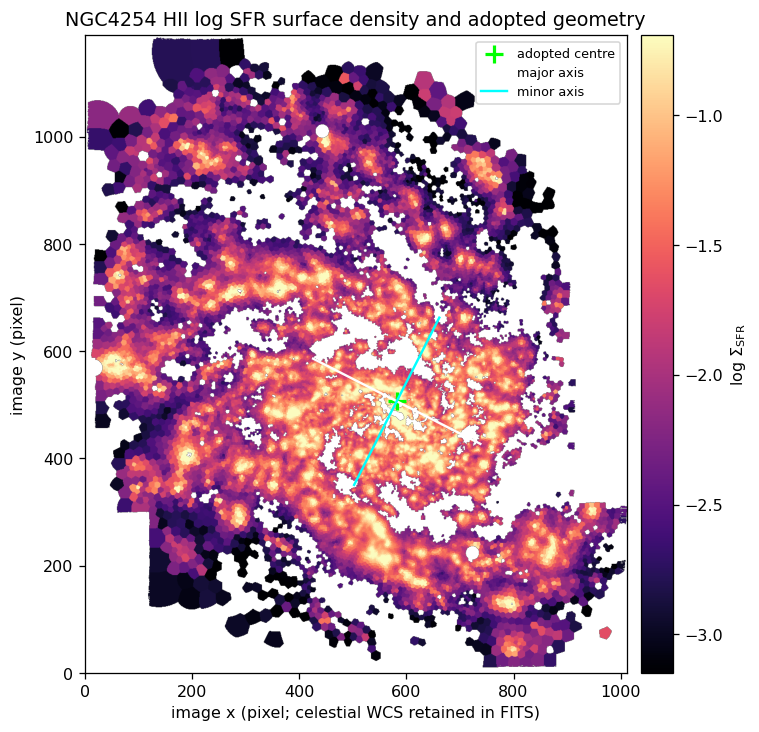

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 7.2))
vmin, vmax = np.nanpercentile(log_sfr_map[finite_sfr], [2, 98])
image = ax.imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
cx, cy = celestial_wcs.world_to_pixel(CENTER)
ax.scatter(cx, cy, marker="+", s=140, linewidth=2.0, color="lime", label="adopted centre")
length_pix = 260.0
pa = np.deg2rad(POSITION_ANGLE_DEG)
# Image x increases approximately east-to-west because CDELT1 is negative; draw axes via sky offsets.
for angle_deg, color, label in [(POSITION_ANGLE_DEG, "white", "major axis"),
                                (POSITION_ANGLE_DEG + 90.0, "cyan", "minor axis")]:
    angle = np.deg2rad(angle_deg)
    dra = np.sin(angle) * 35.0 * u.arcsec
    ddec = np.cos(angle) * 35.0 * u.arcsec
    end1 = CENTER.directional_offset_by(np.arctan2(dra.value, ddec.value) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    end2 = CENTER.directional_offset_by((np.arctan2(dra.value, ddec.value) + np.pi) * u.rad,
                                        np.hypot(dra.value, ddec.value) * u.arcsec)
    x1, y1 = celestial_wcs.world_to_pixel(end1)
    x2, y2 = celestial_wcs.world_to_pixel(end2)
    ax.plot([x1, x2], [y1, y2], color=color, lw=1.5, label=label)
ax.set_xlim(0, log_sfr_map.shape[1]-1)
ax.set_ylim(0, log_sfr_map.shape[0]-1)
ax.set_aspect("equal")
ax.set_xlabel("image x (pixel; celestial WCS retained in FITS)")
ax.set_ylabel("image y (pixel)")
ax.set_title("NGC4254 HII log SFR surface density and adopted geometry")
ax.legend(loc="upper right", fontsize=8)
fig.colorbar(image, ax=ax, pad=0.02, label=r"log $\Sigma_{\rm SFR}$")
plt.show()


## 6. Deproject gas-bin centroids into the galaxy plane

Deprojection asks where each sky position would lie if the inclined disc were viewed face-on. Astropy first calculates tangent-plane offsets from the adopted centre: `east` is positive toward increasing right ascension and `north` is positive toward increasing declination. Multiplying the angular offsets by the 16.5 Mpc angular scale converts them to kpc.

The adopted position angle PA is measured east of north. We rotate the sky offsets into the projected galaxy axes using `major = east*sin(PA) + north*cos(PA)` and `projected_minor = -east*cos(PA) + north*sin(PA)`. Inclination shortens only the apparent minor axis, so the face-on coordinate is `minor = projected_minor/cos(inclination)`. Radius and azimuth are then `R = sqrt(major^2 + minor^2)` and `phi = atan2(minor, major)`.

For projecting a fitted skeleton back to the image, the algebra is reversed: `east = major*sin(PA) - projected_minor*cos(PA)` and `north = major*cos(PA) + projected_minor*sin(PA)`, with `projected_minor = minor*cos(inclination)`. The FITS WCS converts those east/north offsets back to image pixels. The centre, inclination, and PA are fixed rather than fitted from the patchy HII map because they are strongly degenerate with spiral phase, pitch, and winding sign.


1 arcsec = 0.0800 kpc at 16.5 Mpc
Fitting radius: 0.0085 to 13.1635 kpc; no artificial centre or outer cut
Retained bins: 32,552 / 32,552
Represented valid HII pixels: 681,856 / 681,856
FIT_DOMAIN_ALL_VALID_HII_PASS


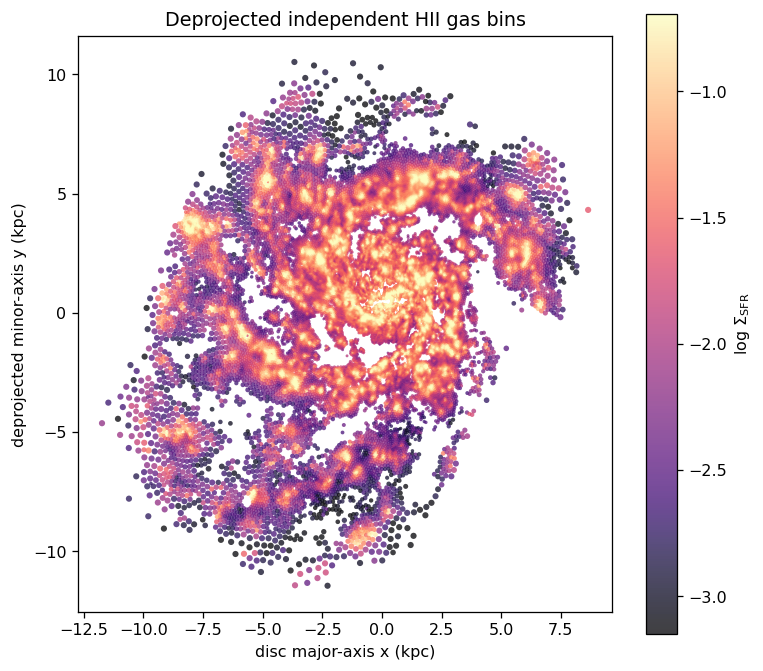

In [5]:
ARCSEC_TO_KPC = DISTANCE_MPC * 1.0e3 / 206265.0


def deproject_sky(ra_deg, dec_deg):
    'Convert ICRS sky coordinates to deprojected major/minor coordinates in kpc.'
    coords = SkyCoord(np.asarray(ra_deg) * u.deg, np.asarray(dec_deg) * u.deg)
    dlon, dlat = CENTER.spherical_offsets_to(coords)
    east_kpc = dlon.to_value(u.arcsec) * ARCSEC_TO_KPC
    north_kpc = dlat.to_value(u.arcsec) * ARCSEC_TO_KPC
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    major = east_kpc * np.sin(pa_rad) + north_kpc * np.cos(pa_rad)
    minor_projected = -east_kpc * np.cos(pa_rad) + north_kpc * np.sin(pa_rad)
    minor = minor_projected / np.cos(inc_rad)
    radius = np.hypot(major, minor)
    azimuth = np.arctan2(minor, major)
    return major, minor, radius, azimuth


# A direct unit check: the adopted sky centre must map to the disc origin.
origin = deproject_sky([CENTER.ra.deg], [CENTER.dec.deg])
assert np.allclose([origin[0][0], origin[1][0]], 0.0, atol=1.0e-10)

values = deproject_sky(bin_table["ra_deg"], bin_table["dec_deg"])
bin_table[["x_disc_kpc", "y_disc_kpc", "radius_kpc", "azimuth_rad"]] = np.column_stack(values)
# Keep every finite HII bin. The logarithmic spiral is undefined only at exactly R=0;
# no valid bin centroid lies exactly at the adopted centre in this product.
fit_mask = np.isfinite(bin_table["radius_kpc"]) & (bin_table["radius_kpc"] > 0.0)
fit_table = bin_table.loc[fit_mask].reset_index(drop=True)
R_IN_KPC = float(fit_table["radius_kpc"].min())
R_OUT_KPC = float(fit_table["radius_kpc"].max())
assert USE_ALL_VALID_HII_BINS
assert len(fit_table) == len(bin_table)
assert int(fit_table["area_pix"].sum()) == int(valid_hii_pixels.sum())
print(f"1 arcsec = {ARCSEC_TO_KPC:.4f} kpc at {DISTANCE_MPC:.1f} Mpc")
print(f"Fitting radius: {R_IN_KPC:.4f} to {R_OUT_KPC:.4f} kpc; no artificial centre or outer cut")
print(f"Retained bins: {len(fit_table):,} / {len(bin_table):,}")
print(f"Represented valid HII pixels: {int(fit_table['area_pix'].sum()):,} / {int(valid_hii_pixels.sum()):,}")
print("FIT_DOMAIN_ALL_VALID_HII_PASS")

fig, ax = plt.subplots(figsize=(7.5, 7.0))
sc = ax.scatter(fit_table["x_disc_kpc"], fit_table["y_disc_kpc"],
                c=fit_table["log_sfr"], s=np.clip(fit_table["area_pix"]**0.5, 2, 15),
                cmap="magma", vmin=vmin, vmax=vmax, alpha=0.75, linewidth=0)
ax.set_aspect("equal")
ax.set_xlabel("disc major-axis x (kpc)")
ax.set_ylabel("deprojected minor-axis y (kpc)")
ax.set_title("Deprojected independent HII gas bins")
fig.colorbar(sc, ax=ax, label=r"log $\Sigma_{\rm SFR}$")
plt.show()


## 7. Fit the axisymmetric exponential background

The KTZ source field separates into an exponential radial background and a fractional spiral modulation. This cell fits `log(Sigma_SFR) = log(lambda0_0) - R/h_R` with area weights and a soft-L1 robust loss, then defines `q = Sigma_SFR/radial_model - 1`. The radial component prevents a simple centre-to-edge decline from masquerading as spiral power. A synthetic exponential assertion checks the fitted scale before the real profile is used.


{'lambda0_0': 0.08853685734511911, 'h_R': 3.14303783409112, 'cost': 18691.642285605718, 'success': True}


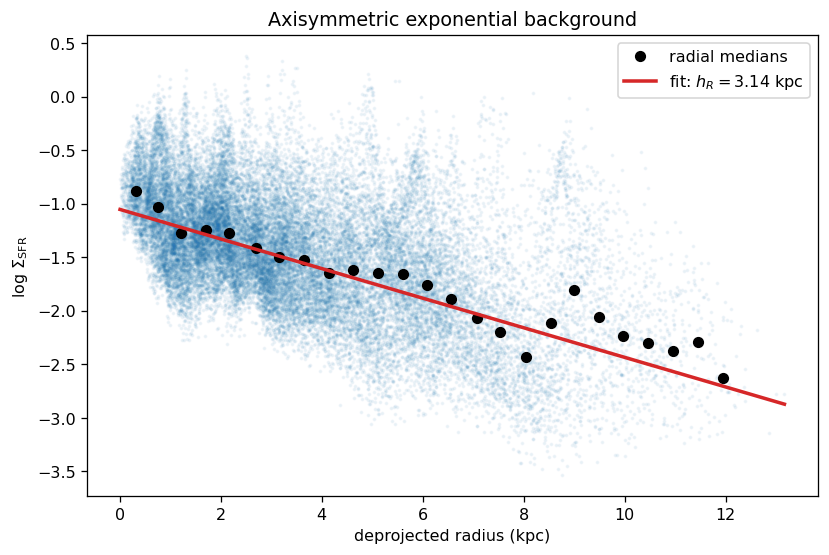

In [6]:
def fit_radial_exponential(radius, sfr_linear, area_weight):
    'Robustly fit lambda0*exp(-R/h_R) in log space.'
    radius = np.asarray(radius, dtype=float)
    sfr_linear = np.asarray(sfr_linear, dtype=float)
    weights = np.sqrt(np.asarray(area_weight, dtype=float))
    valid = (np.isfinite(radius) & np.isfinite(sfr_linear) &
             np.isfinite(weights) & (sfr_linear > 0) & (weights > 0))
    r = radius[valid]
    y = np.log(sfr_linear[valid])
    w = weights[valid] / np.nanmedian(weights[valid])
    initial = np.array([np.nanmedian(y), np.log(3.0)])

    def residual(theta):
        log_lambda0, log_h = theta
        return w * (y - (log_lambda0 - r / np.exp(log_h)))

    result = least_squares(residual, initial, loss="soft_l1", f_scale=0.3,
                           bounds=([-50.0, np.log(0.2)], [50.0, np.log(30.0)]))
    if not result.success:
        raise RuntimeError(result.message)
    return {"lambda0_0": float(np.exp(result.x[0])),
            "h_R": float(np.exp(result.x[1])),
            "cost": float(2.0 * result.cost), "success": True}


# Synthetic unit check of the radial fitter.
r_test = np.linspace(0.5, 8.0, 200)
radial_test = fit_radial_exponential(r_test, 0.025*np.exp(-r_test/3.4), np.ones_like(r_test))
assert abs(radial_test["h_R"] - 3.4) < 0.02

radial_fit = fit_radial_exponential(fit_table["radius_kpc"],
                                    fit_table["sfr_linear"], fit_table["area_pix"])
radial_model = radial_fit["lambda0_0"] * np.exp(-fit_table["radius_kpc"].to_numpy()/radial_fit["h_R"])
fit_table["radial_model"] = radial_model
fit_table["q"] = fit_table["sfr_linear"].to_numpy()/radial_model - 1.0
# Clip only the search initializer; the full fit below uses all un-clipped measurements.
q_lo, q_hi = np.nanpercentile(fit_table["q"], [1, 99])
fit_table["q_search"] = np.clip(fit_table["q"], q_lo, q_hi)
print(radial_fit)

radial_edges = np.linspace(R_IN_KPC, R_OUT_KPC, 28)
radial_index = np.digitize(fit_table["radius_kpc"], radial_edges) - 1
summary_rows = []
for idx in range(len(radial_edges)-1):
    use = radial_index == idx
    if use.sum() >= 10:
        summary_rows.append((np.median(fit_table.loc[use, "radius_kpc"]),
                             np.median(fit_table.loc[use, "log_sfr"]), use.sum()))
radial_summary = pd.DataFrame(summary_rows, columns=["radius_kpc", "median_log_sfr", "n"])

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.scatter(fit_table["radius_kpc"], fit_table["log_sfr"], s=2, alpha=0.06, color="tab:blue")
ax.plot(radial_summary["radius_kpc"], radial_summary["median_log_sfr"], "o", color="black", label="radial medians")
r_line = np.linspace(R_IN_KPC, R_OUT_KPC, 400)
ax.plot(r_line, np.log10(radial_fit["lambda0_0"]*np.exp(-r_line/radial_fit["h_R"])),
        color="tab:red", lw=2.2, label=fr"fit: $h_R={radial_fit['h_R']:.2f}$ kpc")
ax.set(xlabel="deprojected radius (kpc)", ylabel=r"log $\Sigma_{\rm SFR}$",
       title="Axisymmetric exponential background")
ax.legend()
plt.show()


## 8. Define the KTZ spiral phase and search arm number and signed pitch

For every integer `m_arms` from one to four and every signed pitch in the grid, the code computes the weighted complex Fourier coefficient of the radially normalized SFR field. Its magnitude measures how strongly the data line up at that logarithmic-spiral phase, and its angle initializes `Theta0`. The search is an initialization and model-comparison diagnostic; the subsequent full-field optimizer refines the continuous parameters using the un-clipped SFR measurements.


,m_arms,pitch_angle,power,Theta0
0,1,24.25,0.577644,-1.721361
2,3,-25.25,0.380262,2.035998
1,2,14.25,0.356386,1.335860
3,4,13.75,0.279639,1.138224


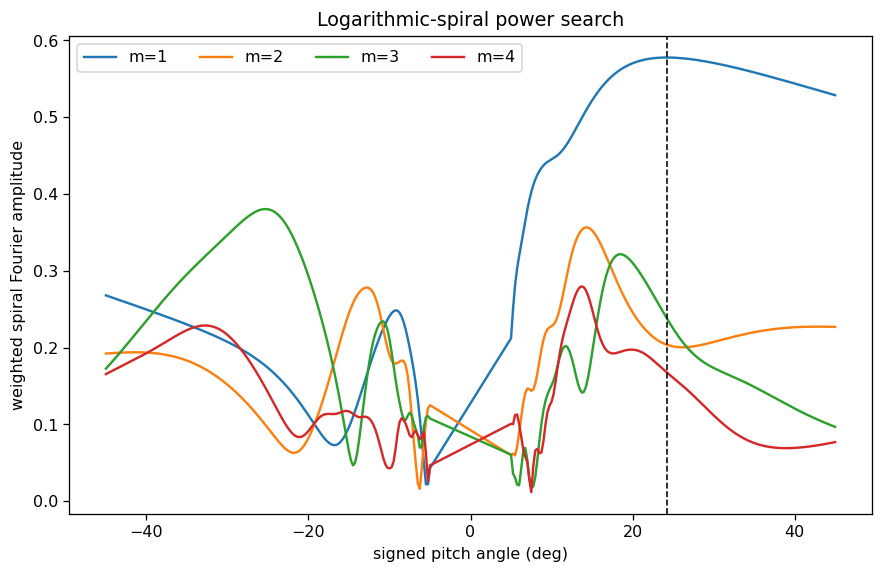

In [7]:
def wrap_angle(angle):
    return np.angle(np.exp(1j*np.asarray(angle)))


def spiral_phase(radius, azimuth, m_arms, pitch_angle, theta0=0.0):
    pitch = np.deg2rad(pitch_angle)
    return ((m_arms/np.tan(pitch))*np.log(np.asarray(radius)/R_REF_KPC)
            - m_arms*np.asarray(azimuth) + theta0)


def arm_profile(theta, harmonic_g, harmonic_alpha):
    theta = np.asarray(theta, dtype=float)
    value = np.zeros_like(theta)
    for n, g, alpha in zip(HARMONIC_N, harmonic_g, harmonic_alpha):
        value += g*np.cos(n*theta + alpha)
    return value


def search_spiral_geometry(radius, azimuth, q, area_weight, pitch_grid=PITCH_GRID_DEG):
    radius = np.asarray(radius, float)
    azimuth = np.asarray(azimuth, float)
    q = np.asarray(q, float)
    w = np.asarray(area_weight, float)
    w = w/w.sum()
    rows = []
    log_r = np.log(radius/R_REF_KPC)
    for m in M_CANDIDATES:
        for pitch in pitch_grid:
            base = (m/np.tan(np.deg2rad(pitch)))*log_r - m*azimuth
            coefficient = np.sum(w*q*np.exp(-1j*base))
            rows.append((int(m), float(pitch), float(np.abs(coefficient)),
                         float(np.angle(coefficient))))
    table = pd.DataFrame(rows, columns=["m_arms", "pitch_angle", "power", "Theta0"])
    best = table.loc[table["power"].idxmax()].to_dict()
    best["m_arms"] = int(best["m_arms"])
    return best, table


discrete_guess, search_table = search_spiral_geometry(
    fit_table["radius_kpc"], fit_table["azimuth_rad"],
    fit_table["q_search"], fit_table["area_pix"])
ranked_candidates = (search_table.sort_values("power", ascending=False)
                     .groupby("m_arms", as_index=False).first()
                     .sort_values("power", ascending=False))
display(ranked_candidates)

fig, ax = plt.subplots(figsize=(9.0, 5.4))
for m, group in search_table.groupby("m_arms"):
    ax.plot(group["pitch_angle"], group["power"], label=f"m={m}")
ax.axvline(discrete_guess["pitch_angle"], color="black", ls="--", lw=1)
ax.set(xlabel="signed pitch angle (deg)", ylabel="weighted spiral Fourier amplitude",
       title="Logarithmic-spiral power search")
ax.legend(ncol=4)
plt.show()


## 9. Fit the harmonic arm profile and refine the complete source-rate field

At fixed trial geometry, a weighted Fourier regression estimates cosine and sine coefficients for harmonic orders one through three. These coefficients are converted to the KTZ convention `g_1=1`, `alpha_1=0`, with `eta` and `Theta0` set by the fundamental. A bounded nonlinear fit then refines the radial scale, pitch, phase, modulation, and higher harmonics together. A dense phase grid penalizes any model whose rate factor becomes non-positive.


In [8]:
def fit_harmonic_profile(radius, azimuth, q, area_weight, m_arms, pitch_angle):
    base = spiral_phase(radius, azimuth, m_arms, pitch_angle, theta0=0.0)
    columns = []
    for n in HARMONIC_N:
        columns.extend([np.cos(n*base), np.sin(n*base)])
    design = np.column_stack(columns)
    sqrt_w = np.sqrt(np.asarray(area_weight, float))
    sqrt_w /= np.nanmedian(sqrt_w)

    def residual(beta):
        # Explicit element-wise contraction avoids stale BLAS floating-point
        # flags being surfaced as spurious matmul warnings during many fits.
        prediction = np.sum(design * beta[None, :], axis=1)
        return sqrt_w * (np.asarray(q, float) - prediction)

    # Bound the initializer coefficients so robust least squares cannot explore
    # non-physical floating-point magnitudes before the full constrained fit.
    result = least_squares(residual, np.zeros(design.shape[1]),
                           bounds=(-5.0, 5.0), loss="soft_l1", f_scale=0.25)
    a1, b1 = result.x[:2]
    eta = float(np.hypot(a1, b1))
    if eta <= 0 or not np.isfinite(eta):
        raise RuntimeError("Fundamental harmonic amplitude is not finite and positive")
    theta0 = float(np.arctan2(-b1, a1) % (2*np.pi))
    harmonic_g = [1.0]
    harmonic_alpha = [0.0]
    for index, n in enumerate(HARMONIC_N[1:], start=1):
        a, b = result.x[2*index:2*index+2]
        harmonic_g.append(float(np.hypot(a, b)/eta))
        delta = np.arctan2(-b, a)
        harmonic_alpha.append(float(wrap_angle(delta - n*theta0)))
    return {"Theta0": theta0, "eta": eta,
            "harmonic_g": np.asarray(harmonic_g),
            "harmonic_alpha": np.asarray(harmonic_alpha),
            "cost": float(2*result.cost), "success": bool(result.success)}


def recover_spiral_parameters(table, q_column="q_search", pitch_grid=PITCH_GRID_DEG):
    discrete, search = search_spiral_geometry(
        table["radius_kpc"], table["azimuth_rad"], table[q_column],
        table["area_pix"], pitch_grid=pitch_grid)
    harmonic = fit_harmonic_profile(
        table["radius_kpc"], table["azimuth_rad"], table[q_column],
        table["area_pix"], discrete["m_arms"], discrete["pitch_angle"])
    recovered = {"m_arms": int(discrete["m_arms"]),
                 "pitch_angle": float(discrete["pitch_angle"]),
                 "Theta0": harmonic["Theta0"], "eta": harmonic["eta"],
                 "harmonic_n": HARMONIC_N.copy(),
                 "harmonic_g": harmonic["harmonic_g"],
                 "harmonic_alpha": harmonic["harmonic_alpha"],
                 "search_power": float(discrete["power"])}
    return recovered, search


def refine_full_model(table, spiral_guess, radial_guess):
    radius = table["radius_kpc"].to_numpy(float)
    azimuth = table["azimuth_rad"].to_numpy(float)
    observed_log = np.log(table["sfr_linear"].to_numpy(float))
    sqrt_w = np.sqrt(table["area_pix"].to_numpy(float))
    sqrt_w /= np.nanmedian(sqrt_w)
    m_arms = int(spiral_guess["m_arms"])
    g0 = np.asarray(spiral_guess["harmonic_g"], float)
    a0 = np.asarray(spiral_guess["harmonic_alpha"], float)
    initial = np.array([np.log(radial_guess["lambda0_0"]), np.log(radial_guess["h_R"]),
                        spiral_guess["pitch_angle"], spiral_guess["Theta0"],
                        np.log(max(spiral_guess["eta"], 1e-4)),
                        g0[1], g0[2], a0[1], a0[2]])
    pitch_bounds = (-60.0, -2.0) if initial[2] < 0 else (2.0, 60.0)
    lower = np.array([-50.0, np.log(0.2), pitch_bounds[0], -4*np.pi,
                      np.log(1e-4), -1.5, -1.5, -np.pi, -np.pi])
    upper = np.array([50.0, np.log(30.0), pitch_bounds[1], 4*np.pi,
                      np.log(2.0), 1.5, 1.5, np.pi, np.pi])
    initial = np.minimum(np.maximum(initial, lower + 1e-6), upper - 1e-6)
    dense_theta = np.linspace(0, 2*np.pi, 4096, endpoint=False)

    def unpack(p):
        return {"lambda0_0": float(np.exp(p[0])), "h_R": float(np.exp(p[1])),
                "pitch_angle": float(p[2]), "Theta0": float(p[3] % (2*np.pi)),
                "eta": float(np.exp(p[4])),
                "harmonic_g": np.array([1.0, p[5], p[6]]),
                "harmonic_alpha": np.array([0.0, p[7], p[8]])}

    def evaluate(p):
        pars = unpack(p)
        theta = spiral_phase(radius, azimuth, m_arms, pars["pitch_angle"], pars["Theta0"])
        factor = 1 + pars["eta"]*arm_profile(theta, pars["harmonic_g"], pars["harmonic_alpha"])
        dense_factor = 1 + pars["eta"]*arm_profile(dense_theta, pars["harmonic_g"], pars["harmonic_alpha"])
        model_log = np.log(pars["lambda0_0"]) - radius/pars["h_R"] + np.log(np.clip(factor, 1e-8, None))
        return model_log, float(np.min(dense_factor))

    def residual(p):
        model_log, min_factor = evaluate(p)
        penalty = min(0.0, min_factor - 1e-3)*1e5
        return np.concatenate([sqrt_w*(observed_log-model_log), [penalty]])

    initial_objective = float(np.sum(residual(initial)**2))
    result = least_squares(residual, initial, bounds=(lower, upper),
                           loss="soft_l1", f_scale=0.25, max_nfev=2500)
    _, minimum_factor = evaluate(result.x)
    refined = unpack(result.x)
    refined.update({"m_arms": m_arms, "harmonic_n": HARMONIC_N.copy(),
                    "objective": float(np.sum(residual(result.x)**2)),
                    "initial_objective": initial_objective,
                    "minimum_rate_factor": minimum_factor,
                    "success": bool(result.success and minimum_factor > 0),
                    "message": result.message})
    if not refined["success"]:
        raise RuntimeError(f"Refinement failed: {result.message}; minimum factor={minimum_factor}")
    return refined


def compare_candidate_modes(table, radial_guess, search, scope="all"):
    'Refine competing arm-number and winding-sign candidates and rank their full objectives.'
    candidate_rows = []
    if scope == "all":
        for m in M_CANDIDATES:
            for sign in (-1, 1):
                group = search[(search["m_arms"] == m) &
                               (np.sign(search["pitch_angle"]) == sign)]
                candidate_rows.append(group.loc[group["power"].idxmax()])
    elif scope == "best_per_sign":
        for sign in (-1, 1):
            group = search[np.sign(search["pitch_angle"]) == sign]
            candidate_rows.append(group.loc[group["power"].idxmax()])
    else:
        raise ValueError(f"Unknown candidate scope: {scope}")

    records = []
    models = {}
    for row in candidate_rows:
        m = int(row["m_arms"])
        pitch = float(row["pitch_angle"])
        sign = int(np.sign(pitch))
        try:
            harmonic = fit_harmonic_profile(
                table["radius_kpc"], table["azimuth_rad"], table["q_search"],
                table["area_pix"], m, pitch)
            guess = {"m_arms": m, "pitch_angle": pitch,
                     "Theta0": harmonic["Theta0"], "eta": harmonic["eta"],
                     "harmonic_n": HARMONIC_N.copy(),
                     "harmonic_g": harmonic["harmonic_g"],
                     "harmonic_alpha": harmonic["harmonic_alpha"]}
            refined = refine_full_model(table, guess, radial_guess)
            models[(m, sign)] = refined
            records.append({"m_arms": m, "winding_sign": sign,
                            "search_pitch": pitch,
                            "pitch_angle": refined["pitch_angle"],
                            "objective": refined["objective"],
                            "eta": refined["eta"], "success": True, "error": ""})
        except Exception as exc:
            records.append({"m_arms": m, "winding_sign": sign,
                            "search_pitch": pitch, "pitch_angle": np.nan,
                            "objective": np.nan, "eta": np.nan, "success": False,
                            "error": f"{type(exc).__name__}: {exc}"})
    comparison = pd.DataFrame(records).sort_values("objective", na_position="last").reset_index(drop=True)
    if not comparison["success"].any():
        raise RuntimeError("Every candidate arm/winding model failed")
    best_row = comparison.loc[comparison["success"]].iloc[0]
    best_model = models[(int(best_row["m_arms"]), int(best_row["winding_sign"]))]
    best_objective = float(best_row["objective"])
    comparison["delta_objective_percent"] = 100.0*(comparison["objective"]/best_objective - 1.0)
    return best_model, comparison, models


## 10. Synthetic injection-recovery test

Before trusting the real fit, this cell generates a known two-armed KTZ field on the actual NGC4254 bin coordinates and sends it through the same discrete search, harmonic regression, and refinement functions. The test checks arm number, pitch, phase, modulation, radial scale, and positivity. This is a geometry-unit test under ideal noise-free conditions; it does not replace observational uncertainty or model-adequacy checks.


In [9]:
INJECTED = {"m_arms": 2, "pitch_angle": 22.0, "Theta0": 0.45,
            "eta": 0.32, "harmonic_g": np.array([1.0, 0.35, 0.15]),
            "harmonic_alpha": np.array([0.0, 0.55, -0.30]),
            "lambda0_0": 0.025, "h_R": 3.4}
synthetic_table = fit_table[["radius_kpc", "azimuth_rad", "area_pix"]].copy()
theta_syn = spiral_phase(synthetic_table["radius_kpc"], synthetic_table["azimuth_rad"],
                         INJECTED["m_arms"], INJECTED["pitch_angle"], INJECTED["Theta0"])
factor_syn = 1 + INJECTED["eta"]*arm_profile(theta_syn, INJECTED["harmonic_g"],
                                             INJECTED["harmonic_alpha"])
synthetic_table["sfr_linear"] = (INJECTED["lambda0_0"]
    * np.exp(-synthetic_table["radius_kpc"]/INJECTED["h_R"]) * factor_syn)
synthetic_table["q_search"] = factor_syn - 1
synthetic_guess, _ = recover_spiral_parameters(synthetic_table)
synthetic_radial = {"lambda0_0": INJECTED["lambda0_0"], "h_R": INJECTED["h_R"]}
synthetic_refined = refine_full_model(synthetic_table, synthetic_guess, synthetic_radial)

phase_error = abs(wrap_angle(synthetic_refined["Theta0"] - INJECTED["Theta0"]))
assert synthetic_refined["m_arms"] == INJECTED["m_arms"]
assert abs(synthetic_refined["pitch_angle"] - INJECTED["pitch_angle"]) < 0.7
assert phase_error < 0.10
assert abs(synthetic_refined["eta"] - INJECTED["eta"]) < 0.04
assert abs(synthetic_refined["h_R"] - INJECTED["h_R"]) < 0.10
assert synthetic_refined["minimum_rate_factor"] > 0
print("SYNTHETIC_RECOVERY_PASS")
display(pd.DataFrame({"injected": [INJECTED["m_arms"], INJECTED["pitch_angle"], INJECTED["Theta0"],
                                         INJECTED["eta"], INJECTED["h_R"]],
                      "recovered": [synthetic_refined["m_arms"], synthetic_refined["pitch_angle"],
                                    synthetic_refined["Theta0"], synthetic_refined["eta"],
                                    synthetic_refined["h_R"]]},
                     index=["m_arms", "pitch_angle", "Theta0", "eta", "h_R"]))


SYNTHETIC_RECOVERY_PASS


,injected,recovered
m_arms,2.00,2.00
pitch_angle,22.00,22.00
Theta0,0.45,0.45
eta,0.32,0.32
h_R,3.40,3.40


## 11. Fit the real NGC4254 HII source field and compare arm modes

The real fit uses every valid HII bin. The clipped fractional residual initializes the search, but the full bounded refinement uses the complete un-clipped SFR measurements. We refine all eight combinations of base arm number `m=1..4` and positive or negative pitch, then rank them by the same full-model objective. This prevents a high Fourier initializer from automatically deciding the final arm number or winding direction.

Here `m_arms` is the **base global Fourier mode**, not necessarily the literal number of visually traceable arm segments. Because the fitted profile includes harmonic orders `n=1,2,3`, a base `m=1` model contains phase-locked spatial `m=1`, `m=2`, and `m=3` structure. NGC4254 is strongly lopsided, its HII mask is asymmetric, and one global logarithmic pitch cannot follow every branch, so a low-objective `m=1` result can describe the dominant asymmetry even when multiple bright arm segments are visible.

The printed comparison table reports how close the alternative modes and the opposite winding sign are. A small objective difference means the apparent direction is not securely determined by this model.


In [10]:
_, search_table = search_spiral_geometry(
    fit_table["radius_kpc"], fit_table["azimuth_rad"],
    fit_table["q_search"], fit_table["area_pix"])
real_fit, candidate_fit_table, candidate_models = compare_candidate_modes(
    fit_table, radial_fit, search_table, scope="all")
best_sign = int(np.sign(real_fit["pitch_angle"]))
opposite_rows = candidate_fit_table[(candidate_fit_table["success"]) &
                                    (candidate_fit_table["winding_sign"] == -best_sign)]
opposite_row = opposite_rows.iloc[0]
opposite_winding_fit = candidate_models[(int(opposite_row["m_arms"]), -best_sign)]
display(candidate_fit_table)
print("GLOBAL_MODE_COMPARISON_COMPLETE")

theta_fit = spiral_phase(fit_table["radius_kpc"], fit_table["azimuth_rad"],
                         real_fit["m_arms"], real_fit["pitch_angle"], real_fit["Theta0"])
fit_table["theta_fit"] = np.mod(theta_fit, 2*np.pi)
fit_table["rate_factor"] = 1 + real_fit["eta"]*arm_profile(
    theta_fit, real_fit["harmonic_g"], real_fit["harmonic_alpha"])
fit_table["model_sfr"] = (real_fit["lambda0_0"]
    * np.exp(-fit_table["radius_kpc"]/real_fit["h_R"]) * fit_table["rate_factor"])
fit_table["residual_dex"] = np.log10(fit_table["sfr_linear"]/fit_table["model_sfr"])

print("REAL_FIT_COMPLETE")
print({key: value for key, value in real_fit.items()
       if key not in {"harmonic_n", "harmonic_g", "harmonic_alpha"}})
print("harmonic_n =", real_fit["harmonic_n"])
print("harmonic_g =", np.round(real_fit["harmonic_g"], 4))
print("harmonic_alpha =", np.round(real_fit["harmonic_alpha"], 4))
print(f"Best opposite-winding candidate: m={opposite_winding_fit['m_arms']}, "
      f"pitch={opposite_winding_fit['pitch_angle']:.2f} deg, "
      f"delta objective={opposite_row['delta_objective_percent']:.3f}%")


,m_arms,winding_sign,search_pitch,pitch_angle,objective,eta,success,error,delta_objective_percent
0,1,1,24.25,17.818937,110431.818658,0.267161,True,,0.000000
1,2,1,14.25,14.028964,112791.456573,0.255207,True,,2.136737
2,3,-1,-25.25,-34.033842,113680.346723,0.211291,True,,2.941659
3,4,-1,-32.75,-32.689901,114789.143567,0.139911,True,,3.945715
4,3,1,18.50,18.231912,115421.296572,0.250688,True,,4.518152
5,1,-1,-45.00,-36.863549,115783.386066,0.110021,True,,4.846038
6,2,-1,-12.75,-11.800128,115842.412061,0.180645,True,,4.899488
7,4,1,13.75,13.833612,116492.169906,0.135217,True,,5.487867


GLOBAL_MODE_COMPARISON_COMPLETE
REAL_FIT_COMPLETE
{'lambda0_0': 0.10184387942142811, 'h_R': 2.876354711637734, 'pitch_angle': 17.818937075516843, 'Theta0': 2.799121459803436, 'eta': 0.26716054413114343, 'm_arms': 1, 'objective': 110431.8186582766, 'initial_objective': 113193.77478056289, 'minimum_rate_factor': 0.6009136736441868, 'success': True, 'message': '`ftol` termination condition is satisfied.'}
harmonic_n = [1 2 3]
harmonic_g = [1.     0.5473 0.8658]
harmonic_alpha = [ 0.     -1.2202 -0.7357]
Best opposite-winding candidate: m=3, pitch=-34.03 deg, delta objective=2.942%


## 12. Spatial-sector bootstrap uncertainty

Neighbouring gas bins are not independent, and bins within one arm segment share large-scale structure. The bootstrap therefore resamples twelve azimuthal sectors rather than individual rows. Each realization refits the radial background, repeats a coarser signed-pitch and arm-number search, and refines the full model. Twenty-four realizations provide a practical stability diagnostic here; their intervals should not be interpreted as a final publication likelihood.


In [11]:
BOOTSTRAP_PITCH_GRID = np.concatenate((np.linspace(-45, -5, 41), np.linspace(5, 45, 41)))


def fit_one_table(table, pitch_grid=PITCH_GRID_DEG):
    radial = fit_radial_exponential(table["radius_kpc"], table["sfr_linear"], table["area_pix"])
    radial_model = radial["lambda0_0"]*np.exp(-table["radius_kpc"].to_numpy()/radial["h_R"])
    work = table.copy()
    q = work["sfr_linear"].to_numpy()/radial_model - 1
    lo, hi = np.nanpercentile(q, [1, 99])
    work["q_search"] = np.clip(q, lo, hi)
    _, search = search_spiral_geometry(
        work["radius_kpc"], work["azimuth_rad"], work["q_search"],
        work["area_pix"], pitch_grid=pitch_grid)
    refined, _, _ = compare_candidate_modes(work, radial, search, scope="best_per_sign")
    return refined


def run_sector_bootstrap(table, n_bootstrap=N_BOOTSTRAP):
    work = table.copy()
    phi = np.mod(work["azimuth_rad"].to_numpy(), 2*np.pi)
    work["sector"] = np.clip(np.floor(phi/(2*np.pi)*N_BOOTSTRAP_SECTORS).astype(int),
                             0, N_BOOTSTRAP_SECTORS-1)
    rows = []
    for iteration, seed in enumerate(np.random.SeedSequence(RNG_SEED).spawn(n_bootstrap)):
        local_rng = np.random.default_rng(seed)
        selected = local_rng.integers(0, N_BOOTSTRAP_SECTORS, N_BOOTSTRAP_SECTORS)
        sample = pd.concat([work.loc[work["sector"] == value] for value in selected],
                           ignore_index=True)
        try:
            result = fit_one_table(sample, pitch_grid=BOOTSTRAP_PITCH_GRID)
            rows.append({"iteration": iteration, "success": True, "error": "",
                         "m_arms": result["m_arms"], "pitch_angle": result["pitch_angle"],
                         "Theta0": result["Theta0"], "lambda0_0": result["lambda0_0"],
                         "h_R": result["h_R"], "eta": result["eta"],
                         "g2": result["harmonic_g"][1], "g3": result["harmonic_g"][2],
                         "alpha2": result["harmonic_alpha"][1],
                         "alpha3": result["harmonic_alpha"][2]})
        except Exception as exc:
            rows.append({"iteration": iteration, "success": False,
                         "error": f"{type(exc).__name__}: {exc}"})
    return pd.DataFrame(rows)


bootstrap_results = run_sector_bootstrap(fit_table)
valid_bootstrap = bootstrap_results.loc[bootstrap_results["success"]].copy()
valid_fraction = len(valid_bootstrap)/len(bootstrap_results)
if valid_fraction < 0.8:
    warnings.warn(f"Only {valid_fraction:.1%} of bootstrap fits succeeded")
continuous_names = ["pitch_angle", "Theta0", "lambda0_0", "h_R", "eta",
                    "g2", "g3", "alpha2", "alpha3"]
bootstrap_summary = pd.DataFrame({name: {
    "p16": valid_bootstrap[name].quantile(0.16),
    "median": valid_bootstrap[name].median(),
    "p84": valid_bootstrap[name].quantile(0.84),
    "n_valid": valid_bootstrap[name].notna().sum()}
    for name in continuous_names}).T
m_frequency = valid_bootstrap["m_arms"].value_counts(normalize=True).sort_index()
print(f"Bootstrap valid fraction: {valid_fraction:.1%}")
display(bootstrap_summary)
display(m_frequency.rename("selection_fraction").to_frame())
pitch_sign_fraction = float((valid_bootstrap["pitch_angle"] > 0).mean())
best_m_fraction = float(m_frequency.max())
fit_stability_note = (f"Best arm-number bootstrap frequency={best_m_fraction:.1%}; "
                      f"positive-pitch frequency={pitch_sign_fraction:.1%}.")
print(fit_stability_note)
if best_m_fraction < 0.8 or 0.1 < pitch_sign_fraction < 0.9:
    print("MODEL_STABILITY_WARNING: the global arm number, pitch, or winding sign is sector-sensitive; "
          "treat the point estimate as a low-dimensional description, not a unique geometry.")


Bootstrap valid fraction: 100.0%


,p16,median,p84,n_valid
pitch_angle,-27.336421,16.344906,19.541915,24.0
Theta0,1.955439,2.557959,4.711170,24.0
lambda0_0,0.086709,0.101756,0.112955,24.0
h_R,2.765947,2.934360,3.155756,24.0
eta,0.280755,0.362735,0.435014,24.0
g2,0.477004,0.653527,0.809495,24.0
g3,0.291572,0.541811,0.839576,24.0
alpha2,-0.665306,-0.338723,1.118636,24.0
alpha3,-0.672887,0.054173,0.586608,24.0


,selection_fraction
m_arms,
1,0.833333
2,0.041667
3,0.125000


Best arm-number bootstrap frequency=83.3%; positive-pitch frequency=62.5%.


## 13. What the “KTZ model” is, and how its fitted ridge is drawn

The middle panel is a **fitted KTZ-compatible SFR morphology model**, not another observed image and not the complete KT18/KT25/KTZ metallicity-mixing theory. It is the smooth parametric reconstruction `lambda0_0 exp(-R/h_R) [1 + eta h(Theta)]` evaluated at the real HII-bin positions. “KTZ-compatible” means that it uses the same logarithmic-spiral phase and harmonic source-rate profile as `KTZ_validation.ipynb`; no diffusion coefficient, enrichment time, metallicity covariance, or stochastic injection field is being fitted here.

The earlier skeleton used the fundamental reference phase `Theta=0`. That is correct only when the total harmonic profile peaks at zero. Once `alpha_2` and `alpha_3` are fitted, the brightest model ridge occurs at `theta_ridge = argmax h(Theta)`, which can be shifted. The skeleton below solves `Theta = theta_ridge + 2*pi*k`, so the curve now traces the actual maximum of the fitted model shown in the middle panel. The best opposite-winding candidate is overlaid as a dashed alternative because the global direction can be model-sensitive.


Maximum sky-disc-pixel round-trip error: 0.0931 pixel
DEPROJECTION_ROUNDTRIP_PASS
Fitted harmonic ridge phase theta_ridge=0.2918 rad
RIDGE_PHASE_CHECK_PASS


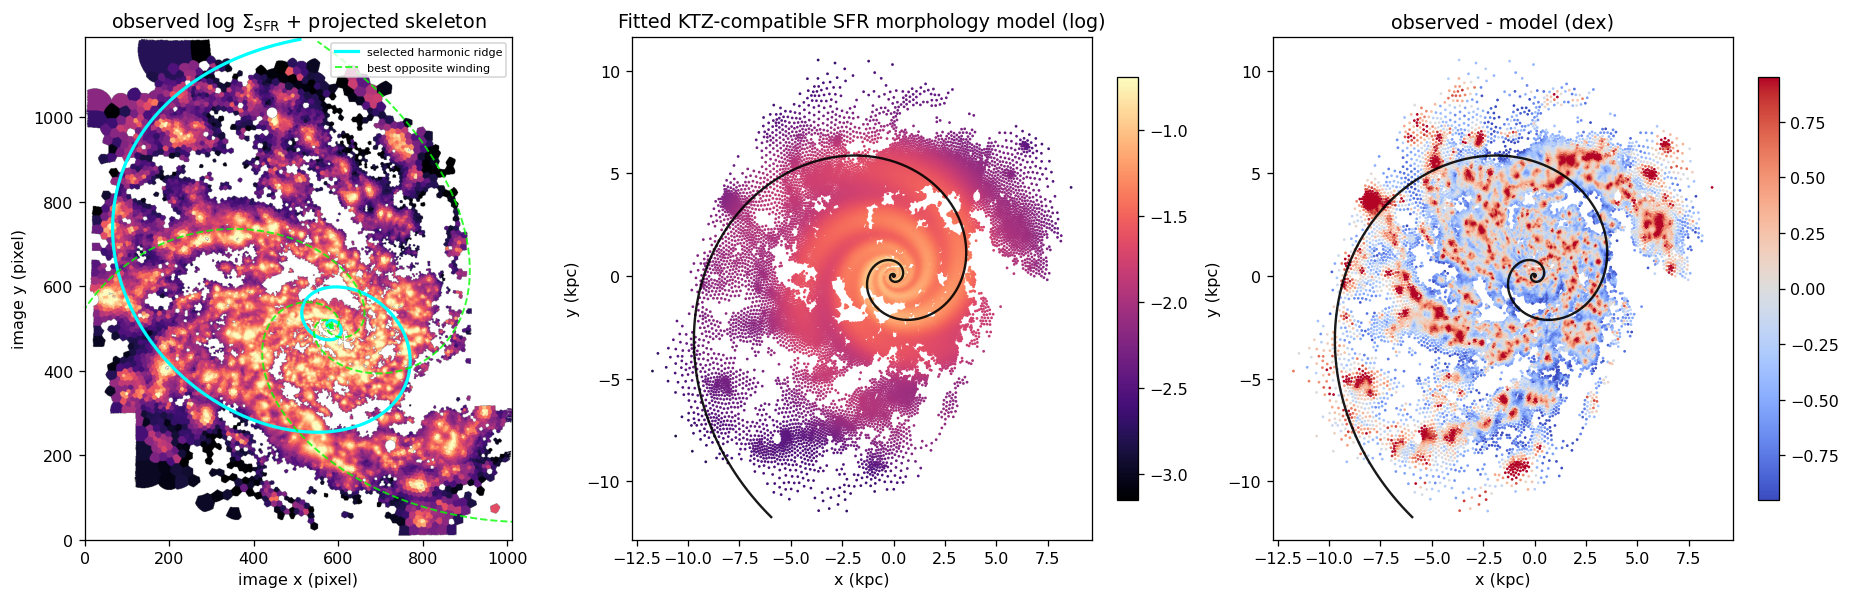

In [12]:
def profile_peak_phase(model):
    phase_grid = np.linspace(0.0, 2.0*np.pi, 32768, endpoint=False)
    profile = arm_profile(phase_grid, model["harmonic_g"], model["harmonic_alpha"])
    return float(phase_grid[np.argmax(profile)])


def skeleton_xy(model, radius_grid):
    curves = []
    m = model["m_arms"]
    pitch = np.deg2rad(model["pitch_angle"])
    theta_ridge = profile_peak_phase(model)
    for k in range(m):
        phi = ((m/np.tan(pitch))*np.log(radius_grid/R_REF_KPC)
               + model["Theta0"] - theta_ridge - 2*np.pi*k)/m
        curves.append((radius_grid*np.cos(phi), radius_grid*np.sin(phi)))
    return curves, theta_ridge


def project_disc_to_pixel(x_disc, y_disc):
    'Invert the fixed deprojection and return image-pixel coordinates.'
    pa_rad = np.deg2rad(POSITION_ANGLE_DEG)
    inc_rad = np.deg2rad(INCLINATION_DEG)
    major = np.asarray(x_disc)
    minor_projected = np.asarray(y_disc)*np.cos(inc_rad)
    east_kpc = major*np.sin(pa_rad) - minor_projected*np.cos(pa_rad)
    north_kpc = major*np.cos(pa_rad) + minor_projected*np.sin(pa_rad)
    east_arcsec = east_kpc/ARCSEC_TO_KPC
    north_arcsec = north_kpc/ARCSEC_TO_KPC
    # spherical_offsets_by expects longitude and latitude offsets directly.
    sky = CENTER.spherical_offsets_by(east_arcsec*u.arcsec, north_arcsec*u.arcsec)
    return celestial_wcs.world_to_pixel(sky)


radius_grid = np.geomspace(R_IN_KPC, R_OUT_KPC, 900)
curves, theta_ridge = skeleton_xy(real_fit, radius_grid)
opposite_curves, opposite_theta_ridge = skeleton_xy(opposite_winding_fit, radius_grid)
# Verify the inverse transform on real bin centroids before trusting an image overlay.
roundtrip_sample = bin_table.iloc[np.linspace(0, len(bin_table)-1, 64, dtype=int)]
roundtrip_x, roundtrip_y = project_disc_to_pixel(roundtrip_sample["x_disc_kpc"],
                                                 roundtrip_sample["y_disc_kpc"])
roundtrip_error_pix = np.hypot(roundtrip_x-roundtrip_sample["x_pix"],
                              roundtrip_y-roundtrip_sample["y_pix"])
# The spherical offsets close to machine precision; WCS frame conversion leaves <0.1 pixel.
assert np.nanmax(roundtrip_error_pix) < 0.1
print(f"Maximum sky-disc-pixel round-trip error: {np.nanmax(roundtrip_error_pix):.4f} pixel")
print("DEPROJECTION_ROUNDTRIP_PASS")
# Verify that the plotted curve is the maximum of the complete harmonic model, not Theta=0.
for x_curve, y_curve in curves:
    phase_on_curve = spiral_phase(np.hypot(x_curve, y_curve), np.arctan2(y_curve, x_curve),
                                  real_fit["m_arms"], real_fit["pitch_angle"], real_fit["Theta0"])
    assert np.nanmax(np.abs(wrap_angle(phase_on_curve-theta_ridge))) < 1e-9
print(f"Fitted harmonic ridge phase theta_ridge={theta_ridge:.4f} rad")
print("RIDGE_PHASE_CHECK_PASS")
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.1), constrained_layout=True)
panels = [("model_sfr", "Fitted KTZ-compatible SFR morphology model (log)", "magma", vmin, vmax),
          ("residual_dex", "observed - model (dex)", "coolwarm",
           -np.nanpercentile(abs(fit_table["residual_dex"]), 95),
           np.nanpercentile(abs(fit_table["residual_dex"]), 95))]
axes[0].imshow(log_sfr_map, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
for x_curve, y_curve in curves:
    xp, yp = project_disc_to_pixel(x_curve, y_curve)
    axes[0].plot(xp, yp, color="cyan", lw=2.0, label="selected harmonic ridge")
for curve_index, (x_curve, y_curve) in enumerate(opposite_curves):
    xp, yp = project_disc_to_pixel(x_curve, y_curve)
    axes[0].plot(xp, yp, color="lime", lw=1.2, ls="--", alpha=0.8,
                 label="best opposite winding" if curve_index == 0 else "_nolegend_")
axes[0].set(xlim=(0, log_sfr_map.shape[1]-1), ylim=(0, log_sfr_map.shape[0]-1),
            xlabel="image x (pixel)", ylabel="image y (pixel)",
            title=r"observed log $\Sigma_{\rm SFR}$ + projected skeleton")
axes[0].set_aspect("equal")
axes[0].legend(loc="upper right", fontsize=7)
for ax, (column, title, cmap, lo, hi) in zip(axes[1:], panels):
    color_value = np.log10(fit_table[column]) if column == "model_sfr" else fit_table[column]
    sc = ax.scatter(fit_table["x_disc_kpc"], fit_table["y_disc_kpc"], c=color_value,
                    s=3, cmap=cmap, vmin=lo, vmax=hi, linewidth=0)
    for x_curve, y_curve in curves:
        ax.plot(x_curve, y_curve, color="black", lw=1.5, alpha=0.9)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x (kpc)")
    ax.set_ylabel("y (kpc)")
    fig.colorbar(sc, ax=ax, shrink=0.84)
plt.show()


## 14. KTZ-style Spiral skeleton and Arm profile

The left panel mirrors the geometry plot in `KTZ_validation.ipynb`, but the solid curve now follows the maximum of the **complete fitted harmonic profile**, not an assumed `Theta=0` ridge. The dashed curve is the best solution with the opposite winding sign; it is shown because direction and pitch are not automatically unique in an asymmetric, incompletely sampled galaxy. The right panel shows each harmonic component, their total `h(Theta)`, and robust phase-folded SFR residuals. The vertical dotted line marks `theta_ridge`, the phase used by the solid skeleton.


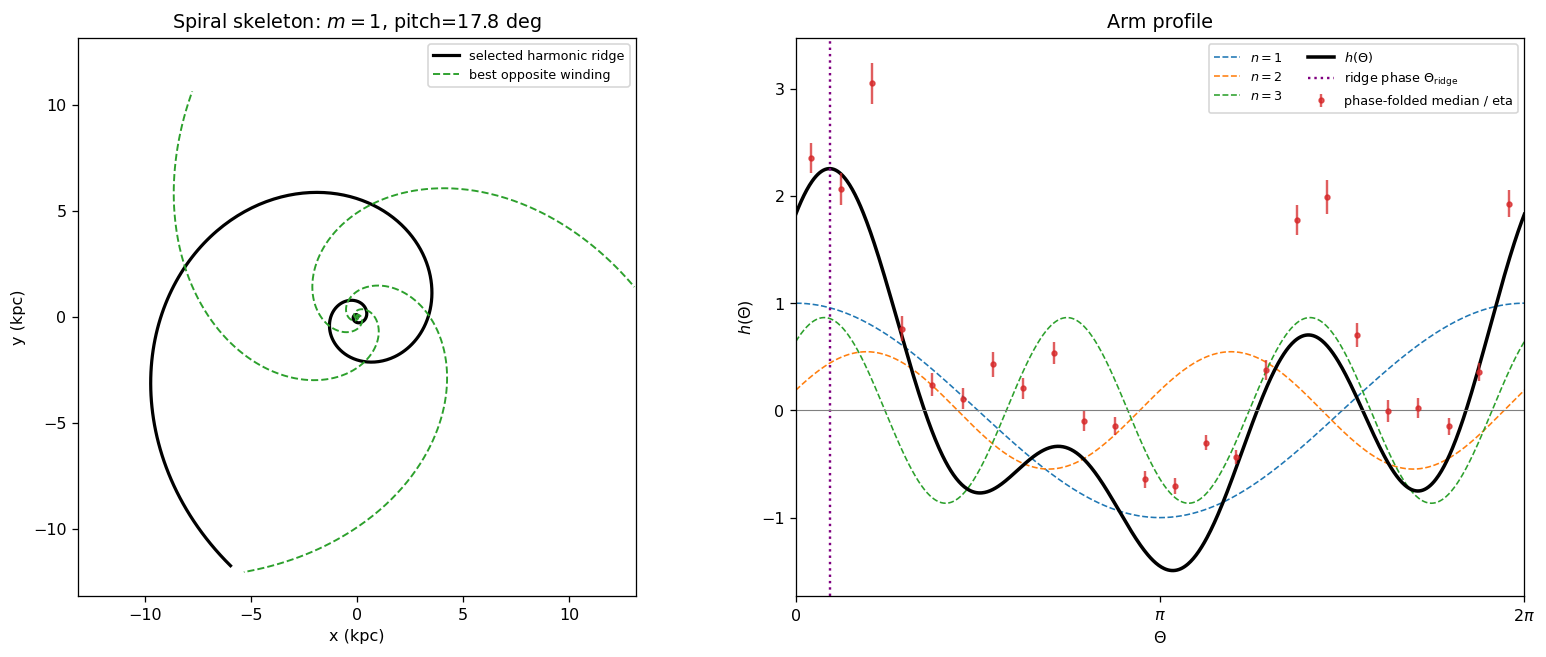

Minimum fitted rate factor: 0.6009
POSITIVITY_CHECK_PASS


In [13]:
theta_grid = np.linspace(0, 2*np.pi, 800)
profile_total = arm_profile(theta_grid, real_fit["harmonic_g"], real_fit["harmonic_alpha"])
rate_factor_grid = 1 + real_fit["eta"]*profile_total
if np.min(rate_factor_grid) <= 0:
    raise ValueError("Fitted source-rate profile becomes non-positive")

phase_edges = np.linspace(0, 2*np.pi, 25)
phase_index = np.digitize(fit_table["theta_fit"], phase_edges)-1
phase_rows = []
for idx in range(len(phase_edges)-1):
    use = phase_index == idx
    if use.sum() >= 10:
        values = fit_table.loc[use, "q"].to_numpy()
        median = np.median(values)
        robust_sigma = 1.4826*np.median(np.abs(values-median))
        phase_rows.append((0.5*(phase_edges[idx]+phase_edges[idx+1]),
                           median, robust_sigma/np.sqrt(use.sum())))
phase_summary = pd.DataFrame(phase_rows, columns=["theta", "q_mean", "q_sem"])

fig, (ax_skeleton, ax_profile) = plt.subplots(1, 2, figsize=(13.5, 5.6), constrained_layout=True)
for x_curve, y_curve in curves:
    ax_skeleton.plot(x_curve, y_curve, "k-", lw=2, label="selected harmonic ridge")
for curve_index, (x_curve, y_curve) in enumerate(opposite_curves):
    ax_skeleton.plot(x_curve, y_curve, color="tab:green", ls="--", lw=1.2,
                     label="best opposite winding" if curve_index == 0 else "_nolegend_")
ax_skeleton.set(xlim=(-R_OUT_KPC, R_OUT_KPC), ylim=(-R_OUT_KPC, R_OUT_KPC),
                xlabel="x (kpc)", ylabel="y (kpc)",
                title=fr"Spiral skeleton: $m={real_fit['m_arms']}$, pitch={real_fit['pitch_angle']:.1f} deg")
ax_skeleton.set_aspect("equal")
ax_skeleton.legend(loc="upper right", fontsize=8)

for n, g, alpha in zip(HARMONIC_N, real_fit["harmonic_g"], real_fit["harmonic_alpha"]):
    ax_profile.plot(theta_grid, g*np.cos(n*theta_grid+alpha), "--", lw=1,
                    label=fr"$n={n}$")
ax_profile.plot(theta_grid, profile_total, "k-", lw=2.2, label=r"$h(\Theta)$")
ax_profile.axvline(theta_ridge, color="purple", ls=":", lw=1.5,
                   label=r"ridge phase $\Theta_{\rm ridge}$")
ax_profile.errorbar(phase_summary["theta"], phase_summary["q_mean"]/real_fit["eta"],
                    yerr=phase_summary["q_sem"]/real_fit["eta"], fmt="o", ms=3,
                    color="tab:red", alpha=0.75, label="phase-folded median / eta")
ax_profile.axhline(0, color="grey", lw=0.7)
ax_profile.set(xlim=(0, 2*np.pi), xlabel=r"$\Theta$", ylabel=r"$h(\Theta)$",
               title="Arm profile")
ax_profile.set_xticks([0, np.pi, 2*np.pi], [r"$0$", r"$\pi$", r"$2\pi$"])
ax_profile.legend(fontsize=8, ncol=2)
plt.show()
print(f"Minimum fitted rate factor: {np.min(rate_factor_grid):.4f}")
print("POSITIVITY_CHECK_PASS")


## 15. Final KTZ-compatible parameter table

This table uses the same variable names as the reference notebook and adds sector-bootstrap percentile intervals where they are meaningful. `m_arms` is discrete, so its stability is reported through the bootstrap selection frequency rather than a continuous error bar. The diffusion and clustering quantities from the first KTZ setup cell are listed as not fitted, preventing morphology alone from being over-interpreted as a mixing measurement.


In [14]:
def interval(name, estimate):
    if name in bootstrap_summary.index:
        row = bootstrap_summary.loc[name]
        return estimate, row["p16"], row["p84"]
    return estimate, np.nan, np.nan


rows = []
pitch_is_multimodal = (valid_bootstrap["pitch_angle"].min() < 0 <
                       valid_bootstrap["pitch_angle"].max())
for variable, estimate, unit in [
    ("R_in", R_IN_KPC, "kpc; innermost valid HII-bin centroid, no artificial hole"),
    ("R_out", R_OUT_KPC, "kpc; outermost valid HII-bin centroid, no quantile cut"),
    ("m_arms", real_fit["m_arms"], "integer global mode"),
    ("pitch_angle", real_fit["pitch_angle"], "signed degrees"),
    ("Theta0", real_fit["Theta0"], "radian modulo 2 pi"),
    ("lambda0_0", real_fit["lambda0_0"], "linear SFR surface-density normalization"),
    ("h_R", real_fit["h_R"], "kpc"),
    ("eta", real_fit["eta"], "dimensionless fundamental modulation")]:
    est, p16, p84 = interval(variable, estimate)
    if variable == "m_arms":
        status = f"global best; bootstrap frequency={m_frequency.get(real_fit['m_arms'], 0.0):.1%}"
    elif variable in {"pitch_angle", "Theta0"} and pitch_is_multimodal:
        status = "fitted; sector bootstrap is multimodal"
    else:
        status = "fitted"
    rows.append((variable, est, p16, p84, unit, status))
rows.extend([
    ("harmonic_n", str(real_fit["harmonic_n"].tolist()), np.nan, np.nan, "integer orders", "fixed"),
    ("harmonic_g", np.array2string(real_fit["harmonic_g"], precision=4), np.nan, np.nan,
     "g1=1 normalization", "fitted"),
    ("harmonic_alpha", np.array2string(real_fit["harmonic_alpha"], precision=4), np.nan, np.nan,
     "radian; alpha1=0", "fitted"),
    ("kappa", np.nan, np.nan, np.nan, "kpc2/Gyr", "not fitted from SFR morphology"),
    ("x0", np.nan, np.nan, np.nan, "kpc", "not fitted from SFR morphology"),
    ("t_star", np.nan, np.nan, np.nan, "Gyr", "not fitted from SFR morphology"),
    ("source clustering", np.nan, np.nan, np.nan, "Thomas-process parameters",
     "not fitted from SFR morphology")])
parameter_table = pd.DataFrame(rows, columns=["reference_variable", "estimate", "p16", "p84",
                                              "unit_or_convention", "status"])
display(parameter_table)
print("Bootstrap m selection fractions:")
display(m_frequency.rename("selection_fraction").to_frame())


,reference_variable,estimate,p16,p84,unit_or_convention,status
0,R_in,0.008545,NaN,NaN,"kpc; innermost valid HII-bin centroid, no arti...",fitted
1,R_out,13.16348,NaN,NaN,"kpc; outermost valid HII-bin centroid, no quan...",fitted
2,m_arms,1,NaN,NaN,integer global mode,global best; bootstrap frequency=83.3%
3,pitch_angle,17.818937,-27.336421,19.541915,signed degrees,fitted; sector bootstrap is multimodal
4,Theta0,2.799121,1.955439,4.711170,radian modulo 2 pi,fitted; sector bootstrap is multimodal
5,lambda0_0,0.101844,0.086709,0.112955,linear SFR surface-density normalization,fitted
6,h_R,2.876355,2.765947,3.155756,kpc,fitted
7,eta,0.267161,0.280755,0.435014,dimensionless fundamental modulation,fitted
8,harmonic_n,"[1, 2, 3]",NaN,NaN,integer orders,fixed
9,harmonic_g,[1. 0.5473 0.8658],NaN,NaN,g1=1 normalization,fitted


Bootstrap m selection fractions:


,selection_fraction
m_arms,
1,0.833333
2,0.041667
3,0.125000


## 16. Interpretation limits and the next KTZ step

The fitted parameters describe the best global KTZ-compatible source geometry found in all finite HII SFR bins under the fixed centre, distance, inclination, position angle, and adaptive-bin mask. There is no artificial central hole and no outer-radius quantile cut. One centroid per adaptive bin is used to avoid pseudo-replication, while the bin's member-pixel area ensures that all 681,856 valid HII pixels contribute to the spatial weighting.

`m_arms` is the base global mode, not a catalogue count of visible arm segments. Harmonics of a base `m=1` phase add phase-locked spatial `m=2` and `m=3` power. The candidate table, opposite-winding overlay, skeleton, and residual panels must therefore be interpreted together: a slightly lower global objective does not imply that every asymmetric branch is captured by one pitch angle or that the winding direction is uniquely known. Bootstrap variation across sectors measures sensitivity to which parts of this disturbed disc are sampled.

These parameters can now define an external source-field template for a later oxygen-abundance correlation forward model. They do **not** measure `kappa`, `x0`, `t_star`, enrichment delay, source clustering, arm pattern speed, or arm lifetime. A metallicity analysis should keep the SFR-derived geometry fixed or propagate its bootstrap uncertainty, apply the real oxygen mask and binning to every mock, and compare homogeneous KT18, clustered KT18, and spiral-modulated KTZ models.
